In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/awsaf49
/kaggle/input/datasets/awsaf49/mnist-dataset
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/0
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/3
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/1
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/4
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/9
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/6
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing
/kaggle/input/datasets/awsaf49/mnist-dataset/

In [6]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

dataset_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png"

train_images = []
test_images = []

for digit in range(10):

    train_folder = os.path.join(dataset_path, "training", str(digit))
    test_folder = os.path.join(dataset_path, "testing", str(digit))

    print(train_folder)   # Optional: shows which folder is being loaded

    for img in os.listdir(train_folder):
        image = load_img(
            os.path.join(train_folder, img),
            color_mode="grayscale",
            target_size=(28, 28)
        )
        image = img_to_array(image) / 255.0
        train_images.append(image)

    for img in os.listdir(test_folder):
        image = load_img(
            os.path.join(test_folder, img),
            color_mode="grayscale",
            target_size=(28, 28)
        )
        image = img_to_array(image) / 255.0
        test_images.append(image)

x_train = np.array(train_images)
x_test = np.array(test_images)

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/0
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/1
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/3
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/4
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/6
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/9
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


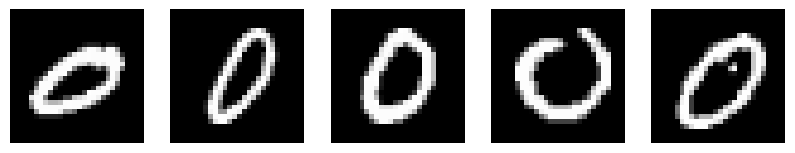

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [8]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

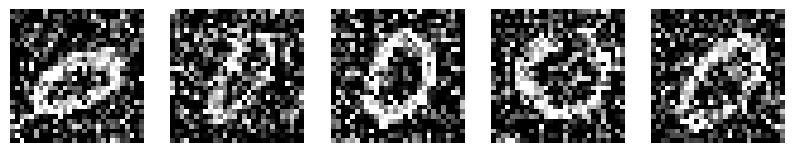

In [9]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [10]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

2026-07-27 04:00:22.415912: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 131ms/step - loss: 0.1659 - val_loss: 0.1163
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - loss: 0.1134 - val_loss: 0.1091
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 125ms/step - loss: 0.1077 - val_loss: 0.1052
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - loss: 0.1044 - val_loss: 0.1025
Epoch 5/10
 34/469 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - loss: 0.1032

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()